<a href="https://colab.research.google.com/github/Nicolas-Bernal/Simulacion-Estadistica/blob/main/Segundo%20Corte/01_Descomposicion_Espectral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nicolas Bernal
## Simulacion Estadistica

In [24]:
# Librerias

install.packages("MASS")
install.packages("mvtnorm")


library(MASS)
library(mvtnorm)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# Descomposicion Espectral

La descomposición espectral (o descomposición en autovalores y autovectores) es un método del álgebra lineal que descompone una matriz cuadrada simétrica e inversible $\boldsymbol{\Sigma}$ en la forma:$$\boldsymbol{\Sigma} = \mathbf{V} \mathbf{\Lambda} \mathbf{V}^T$$

* $\mathbf{V}$ es una matriz ortogonal cuyas columnas son los autovectores ortonormales de $\boldsymbol{\Sigma}$.
* $\mathbf{\Lambda}$ es una matriz diagonal que contiene los autovalores $(\lambda_1, \lambda_2, \dots, \lambda_p)$ en la diagonal principal.

In [7]:
mu = c(0,0)
Sigma = matrix(c(1,.9,.9,1),ncol = 2, nrow = 2)
mu
sigma


[1] 0 0

1.0,0.9
0.9,1.0


[1] -0.01850618 -0.01996518
          [,1]      [,2]
[1,] 1.0000000 0.9012113
[2,] 0.9012113 1.0000000


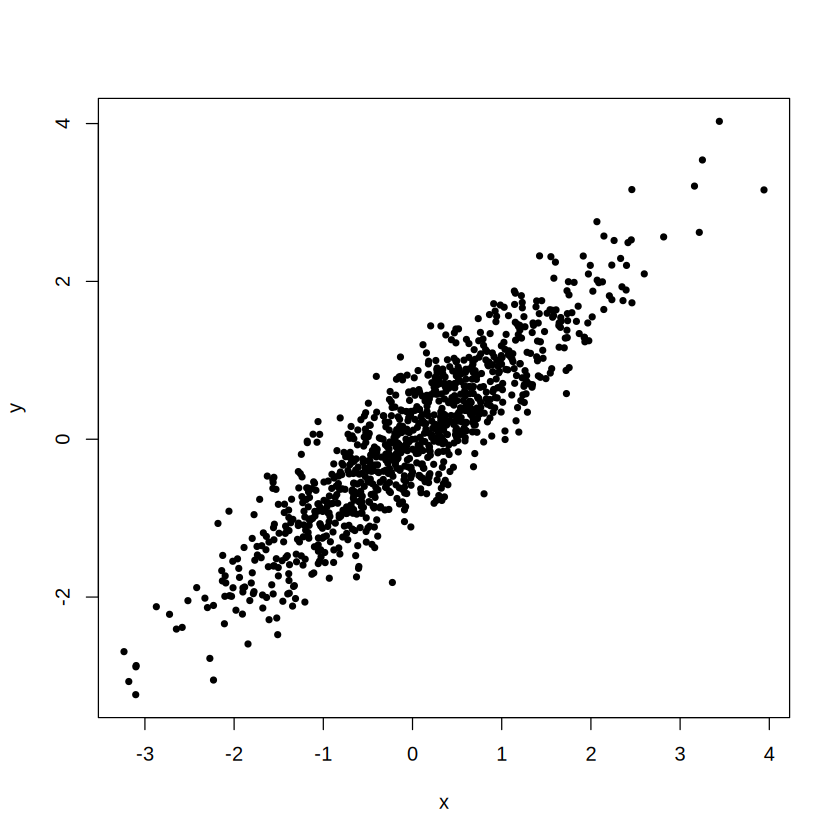

In [17]:
set.seed(1)

rmvn.eigen = function(n, mu, Sigma) {
    # generate n random vectors from MVN(mu, Sigma)
    # dimension is inferred from mu and Sigma

    d = length(mu)

    ev = eigen(Sigma, symmetric = TRUE)

    lambda = ev$values

    V = ev$vectors

    R = V %*% diag(sqrt(lambda)) %*% t(V)

    Z = matrix(rnorm(n*d), nrow = n, ncol = d)

    X = Z %*% R + matrix(mu, n, d, byrow = TRUE)

    X
  }

# generate the sample

X = rmvn.eigen(1000, mu, Sigma)

plot(X, xlab = "x", ylab = "y", pch = 20)
print(colMeans(X))
print(cor(X))


## Eigen()

Una variante del metodo anterior tambien puede ser que el siguente que es una descomposicion en valores singulares en lugar de descomposicion espectral eigen()

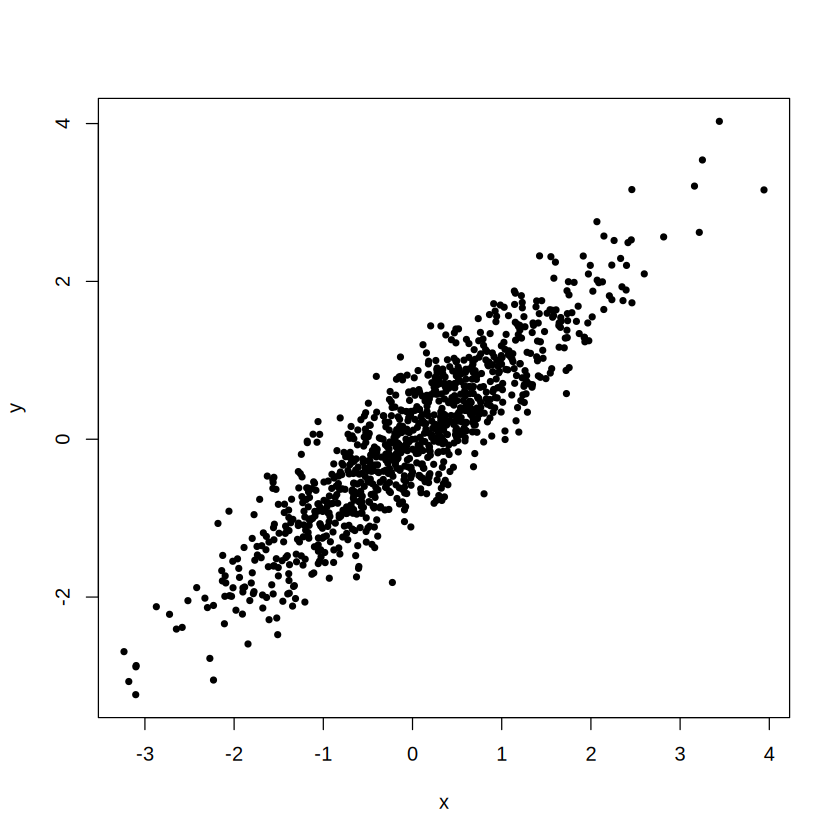

In [18]:
set.seed(1)

### (SVD method)

rmvn.svd = function(n, mu, Sigma) {

    # generate n random vectors from MVN(mu, Sigma)
    # dimension is inferred from mu and Sigma

    d = length(mu)

    S = svd(Sigma)

    R = S$u %*% diag(sqrt(S$d)) %*% t(S$v) #sq. root Sigma

    Z = matrix(rnorm(n*d), nrow=n, ncol=d)

    X = Z %*% R + matrix(mu, n, d, byrow=TRUE)

    X

  }

plot(X,xlab = "x",ylab = "y", pch = 20)

## Choleski

*Es una variante igual al metodo anterior pero ahora usando una funcion llamada choleski que corresponde a su propia descomposicion en una matriz simetrica superior lo que hace facilitar mucho mas los calculos*

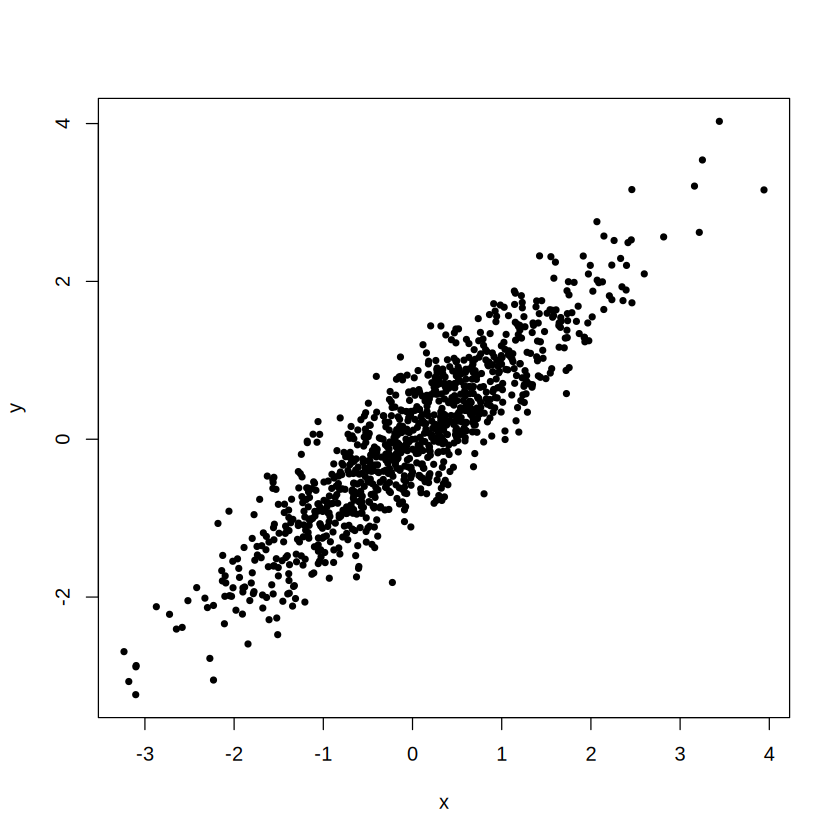

In [20]:
### (Choleski factorization method)
set.seed(1)

rmvn.Choleski = function(n, mu, Sigma) {
    # generate n random vectors from MVN(mu, Sigma)

    # dimension is inferred from mu and Sigma

    d = length(mu)

    Q = chol(Sigma) # Choleski factorization of Sigma

    Z = matrix(rnorm(n*d), nrow=n, ncol=d)

    X = Z %*% Q + matrix(mu, n, d, byrow=TRUE)

    X
  }
plot(X,xlab = "x",ylab = "y",pch = 20)


Sepal.Length  Sepal.Width Petal.Length  Petal.Width 
       6.588        2.974        5.552        2.026

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,0.40434286,0.09376327,0.30328980,0.04909388
Sepal.Width,0.09376327,0.10400408,0.07137959,0.04762857
Petal.Length,0.30328980,0.07137959,0.30458776,0.04882449
Petal.Width,0.04909388,0.04762857,0.04882449,0.07543265


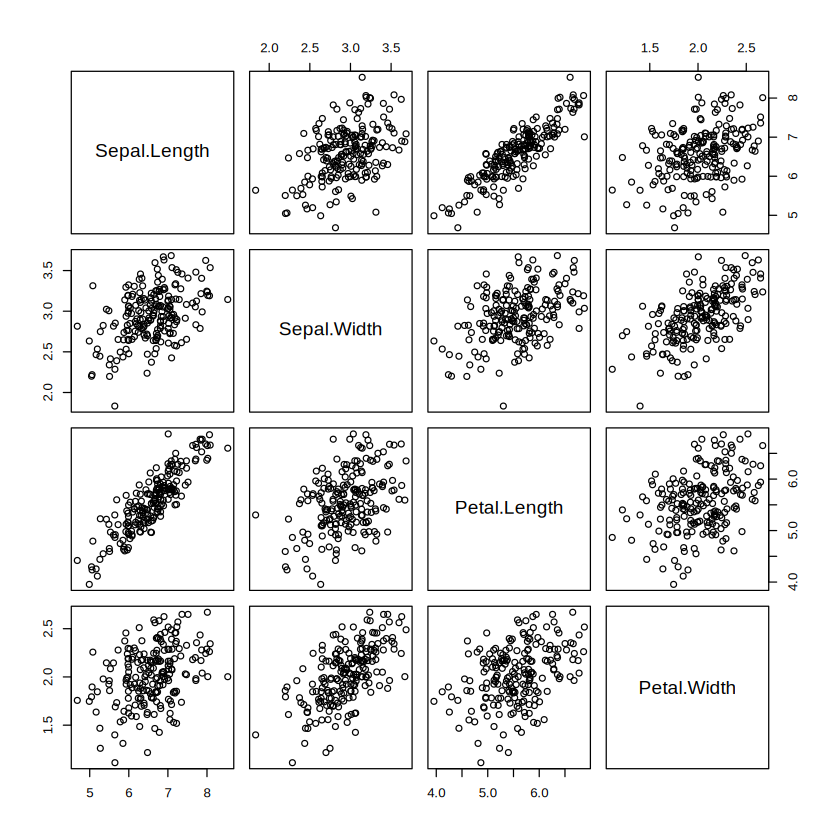

In [22]:
#generating the samples according to the mean and covariance
#structure as the four-dimensional iris virginica data

y = subset(x=iris, Species=="virginica")[, 1:4]

mu = colMeans(y)

Sigma = cov(y)

mu
Sigma

#now generate MVN data with this mean and covariance
X = rmvn.Choleski(200, mu, Sigma)
pairs(X)


In [25]:
### (Comparing performance of MVN generators)

library(MASS)
library(mvtnorm)
n = 100          #sample size
d = 30           #dimension
N = 2000         #iterations
mu = numeric(d)

set.seed(100)
system.time(for (i in 1:N)
  rmvn.eigen(n, mu, cov(matrix(rnorm(n*d), n, d))))
set.seed(100)
system.time(for (i in 1:N)
  rmvn.svd(n, mu, cov(matrix(rnorm(n*d), n, d))))
set.seed(100)
system.time(for (i in 1:N)
  rmvn.Choleski(n, mu, cov(matrix(rnorm(n*d), n, d))))
set.seed(100)
system.time(for (i in 1:N)
  mvrnorm(n, mu, cov(matrix(rnorm(n*d), n, d))))
set.seed(100)
system.time(for (i in 1:N)
  rmvnorm(n, mu, cov(matrix(rnorm(n*d), n, d))))

   user  system elapsed 
  1.173   0.002   1.176 

   user  system elapsed 
  1.272   0.001   1.283 

   user  system elapsed 
  0.830   0.001   0.831 

   user  system elapsed 
  1.206   0.003   1.210 

   user  system elapsed 
  1.587   0.001   1.590 

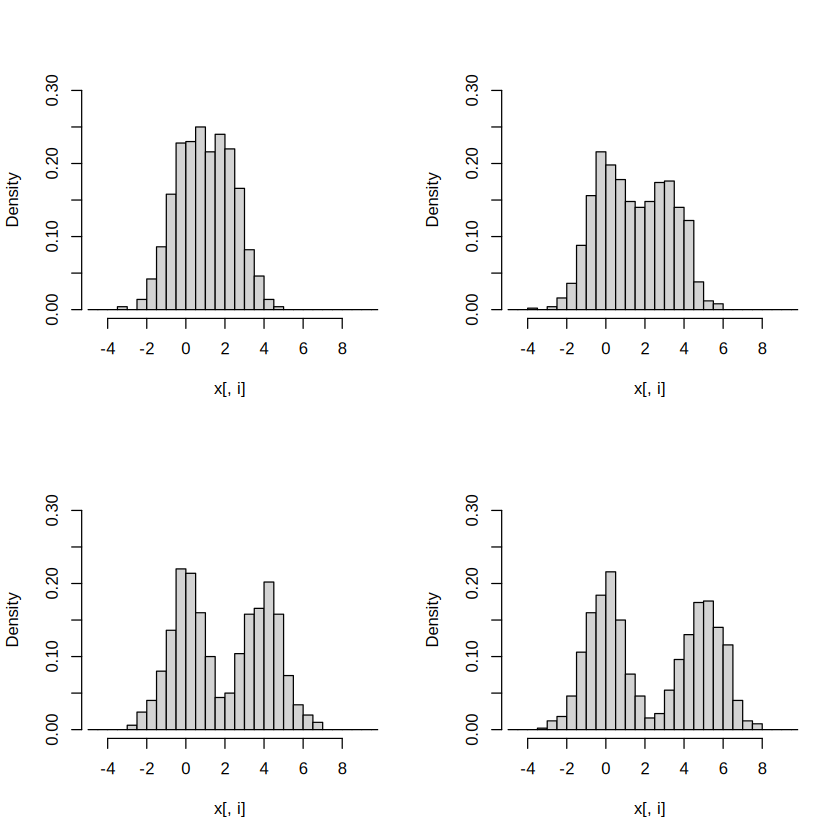

In [27]:
#(Multivariate normal mixture)

library(MASS)  #for mvrnorm

loc.mix = function(n, p, mu1, mu2, Sigma) {

  #generate sample from BVN location mixture

  n1 = rbinom(1, size = n, prob = p)

  n2 = n - n1

  x1 = mvrnorm(n1, mu = mu1, Sigma)

  x2 = mvrnorm(n2, mu = mu2, Sigma)

  X = rbind(x1, x2)            #combine the samples

  return(X[sample(1:n), ])      #mix them
}

x = loc.mix(1000, .5, rep(0, 4), 2:5, Sigma = diag(4))

r = range(x) * 1.2

par(mfrow = c(2, 2))

for (i in 1:4)
  hist(x[ , i], xlim = r, ylim = c(0, .3), freq = FALSE,
       main = "", breaks = seq(-5, 10, .5))


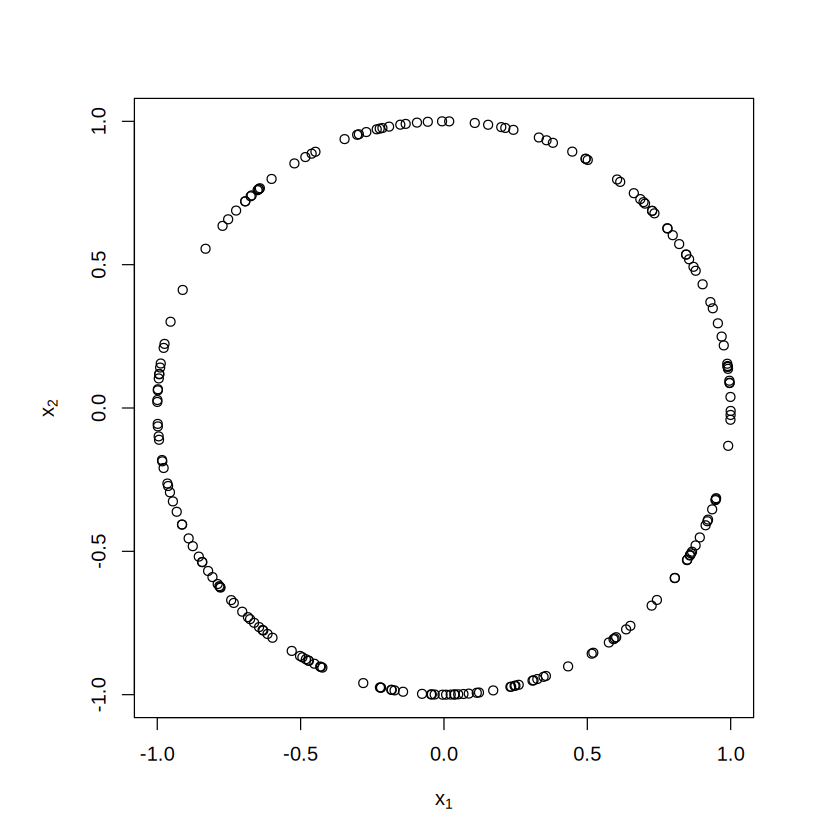

In [28]:
runif.sphere <- function(n, d) {

  # return a random sample uniformly distributed

  # on the unit sphere in R ^d

  M = matrix(rnorm(n*d), nrow = n, ncol = d)

  L = apply(M, MARGIN = 1,

             FUN = function(x){sqrt(sum(x*x))})

  D = diag(1 / L)

  U = D %*% M

  U
}

#generate a sample in d=2 and plot

X = runif.sphere(200, 2)

par(pty = "s")

plot(X, xlab = bquote(x[1]), ylab = bquote(x[2]))

par(pty = "m")
